# 09 — Dynamic Beta Hedging

## Purpose

Apply a rolling 60-month OLS beta hedge to transform the long-only strategies
into market-neutral alpha streams. This notebook also serves as the **complete
hedge instrument analysis** (absorbing the former NB12).

### Hedge Instrument Choice

| Instrument | Type | Dividend | Tradeable | Coverage |
|------------|------|----------|-----------|----------|
| **EEM** (primary) | ETF total return | Included | Yes — can short shares | 2003-2024 |
| MSCI EM (robustness) | Price index | Excluded | No — not tradeable | 2001-2025 |

**Why EEM is the primary hedge:** When shorting to hedge, you owe dividends on
the borrowed shares. EEM's total return captures this cost (~2.0-2.5%/yr),
giving a more honest measure of hedged alpha. The MSCI EM price index
overstates alpha by the dividend yield because the hedge "receives" dividends
that a real short position would not.

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())

# ── Load EEM (primary, total-return) ──
eem_raw = pd.read_csv('../data/eem_returns_monthly.csv', index_col=0, parse_dates=True)
eem_raw['mret'] = pd.to_numeric(eem_raw['mret'], errors='coerce')
eem_raw = eem_raw.dropna(subset=['mret'])
eem_raw.index = eem_raw.index.to_period('M').to_timestamp()
eem_ret = eem_raw['mret'].sort_index()
eem_ret = eem_ret[~eem_ret.index.duplicated(keep='last')]

# ── Load MSCI EM (secondary, price-only) ──
msci_price = pd.read_excel('../data/msci_em_index_price.xlsx', index_col=0, parse_dates=True)
msci_price = msci_price.dropna().sort_index()
msci_ret_raw = msci_price.iloc[:, 0].pct_change(fill_method=None).dropna()
msci_ret_raw.index = msci_ret_raw.index.to_period('M').to_timestamp()
msci_ret = msci_ret_raw.sort_index()
msci_ret = msci_ret[~msci_ret.index.duplicated(keep='last')]

# ── Load strategy returns ──
pc_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_all_portfolio_returns.csv',
                      index_col=0, parse_dates=True)
COL_A = 'TO_MVO_All6EW_LW_60m'     # Strategy A
COL_B = 'Momentum_All6EW_LW_60m'   # Strategy B

# ── Turnover ──
stock_to_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
stock_to = stock_to_df.loc['All6-EW', 'avg_monthly_turnover']
mc_scores = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
pc_to = {}
for _, row in mc_scores.iterrows():
    if 'All6EW' in row['Strategy']:
        pc_to[row['PC']] = row['PC_TO']

TO_A = stock_to + pc_to.get('TO_MVO', 0.007)
TO_B = stock_to + pc_to.get('Momentum', 0.096)
TC_A = TO_A * (REALISTIC_TC_BPS / 10_000)
TC_B = TO_B * (REALISTIC_TC_BPS / 10_000)

STRATS = {
    '(a) All6-EW + TO_MVO':    {'col': COL_A, 'tc': TC_A, 'to': TO_A},
    '(b) All6-EW + Momentum':  {'col': COL_B, 'tc': TC_B, 'to': TO_B},
}

# ── Align to EEM common dates ──
common_eem = pc_ret.index.intersection(eem_ret.index)
holdout_eem = sorted([d for d in common_eem if d >= HOLD_START])

print(f'EEM coverage: {eem_ret.index[0].strftime("%Y-%m")} to {eem_ret.index[-1].strftime("%Y-%m")} ({len(eem_ret)} months, total-return)')
print(f'MSCI coverage: {msci_ret.index[0].strftime("%Y-%m")} to {msci_ret.index[-1].strftime("%Y-%m")} ({len(msci_ret)} months, price-only)')
print(f'Holdout (EEM): {len(holdout_eem)} months ({holdout_eem[0].strftime("%Y-%m")} to {holdout_eem[-1].strftime("%Y-%m")})')
print(f'Turnover: TO_MVO={TO_A:.3f}, Momentum={TO_B:.3f}')
print(f'TC drag @{REALISTIC_TC_BPS:.0f}bp: TO_MVO={TC_A*12:.2%}/yr, Momentum={TC_B*12:.2%}/yr')

EEM coverage: 2003-05 to 2024-09 (257 months, total-return)
MSCI coverage: 2001-05 to 2025-05 (289 months, price-only)
Holdout (EEM): 69 months (2019-01 to 2024-09)
Turnover: TO_MVO=0.192, Momentum=0.280
TC drag @45bp: TO_MVO=1.03%/yr, Momentum=1.51%/yr


## 2. Hedge Instrument Comparison: EEM vs MSCI EM

Before hedging, we compare the two instruments to quantify the dividend drag
and establish EEM as the realistic benchmark.

Overlap period: 2003-05 to 2024-09 (257 months)

=== BENCHMARK COMPARISON ===
  Pearson correlation:   0.9943
  Spearman correlation:  0.9931
  Annualized TE:         2.18%
  Mean return diff (ann): +1.81% (EEM > MSCI)
  This 1.8%/yr gap = EM dividend yield

=== MONTHLY RETURN STATISTICS ===
           EEM     MSCI    Diff
count 257.0000 257.0000  0.0000
mean    0.0087   0.0071  0.0015
std     0.0589   0.0590 -0.0001
min    -0.2571  -0.2750  0.0178
25%    -0.0260  -0.0252 -0.0008
50%     0.0091   0.0065  0.0026
75%     0.0435   0.0442 -0.0008
max     0.1604   0.1666 -0.0062


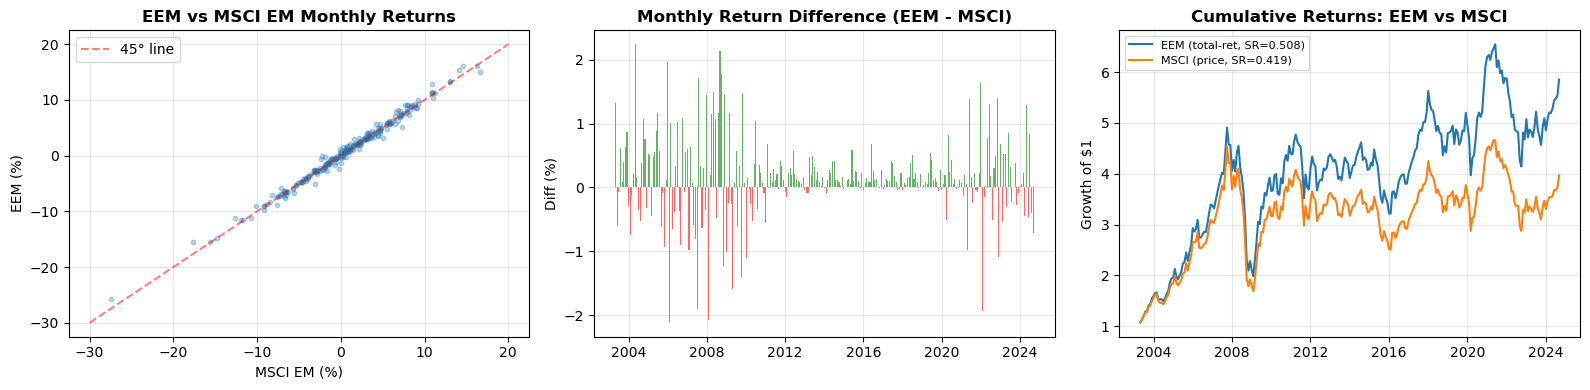

In [2]:
from scipy import stats

both = pd.concat([eem_ret.rename('EEM'), msci_ret.rename('MSCI')], axis=1).dropna()
print(f'Overlap period: {both.index[0].strftime("%Y-%m")} to {both.index[-1].strftime("%Y-%m")} ({len(both)} months)')

pearson_r = both['EEM'].corr(both['MSCI'])
spear_r = stats.spearmanr(both['EEM'], both['MSCI'])[0]
te = (both['EEM'] - both['MSCI']).std() * np.sqrt(12)
ret_diff = (both['EEM'].mean() - both['MSCI'].mean()) * 12

print(f'\n=== BENCHMARK COMPARISON ===')
print(f'  Pearson correlation:   {pearson_r:.4f}')
print(f'  Spearman correlation:  {spear_r:.4f}')
print(f'  Annualized TE:         {te:.2%}')
print(f'  Mean return diff (ann): {ret_diff:+.2%} (EEM > MSCI)')
print(f'  This {abs(ret_diff):.1%}/yr gap = EM dividend yield')

print(f'\n=== MONTHLY RETURN STATISTICS ===')
stats_df = both.describe()
stats_df['Diff'] = stats_df['EEM'] - stats_df['MSCI']
print(stats_df.to_string(float_format=lambda x: f'{x:.4f}'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.scatter(both['MSCI']*100, both['EEM']*100, alpha=0.3, s=10)
ax.plot([-30,20],[-30,20], 'r--', alpha=0.5, label='45° line')
ax.set_xlabel('MSCI EM (%)'); ax.set_ylabel('EEM (%)')
ax.set_title('EEM vs MSCI EM Monthly Returns', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
diff = (both['EEM'] - both['MSCI']) * 100
ax.bar(diff.index, diff.values, width=20, alpha=0.6, color=['green' if d>0 else 'red' for d in diff.values])
ax.set_title('Monthly Return Difference (EEM - MSCI)', fontweight='bold')
ax.set_ylabel('Diff (%)'); ax.grid(True, alpha=0.3)

ax = axes[2]
cum_eem = (1+both['EEM']).cumprod()
cum_msci = (1+both['MSCI']).cumprod()
ax.plot(cum_eem.index, cum_eem.values, lw=1.5, label=f'EEM (total-ret, SR={ann_sharpe(both["EEM"]):.3f})')
ax.plot(cum_msci.index, cum_msci.values, lw=1.5, label=f'MSCI (price, SR={ann_sharpe(both["MSCI"]):.3f})')
ax.set_title('Cumulative Returns: EEM vs MSCI', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb09_benchmark_comparison.pdf', bbox_inches='tight')
plt.show()

## 3. Dividend Impact Analysis

When hedging via a short position, the hedger owes dividends on the short leg.
A price-index hedge ignores this cost, inflating apparent alpha.
We quantify this via dividend-adjusted MSCI scenarios and the empirical
EEM/MSCI gap.

In [3]:
# Load signal data for dividend yield estimate
from src.data_loader import load_signal_data
df = load_signal_data('../data')

avg_dy = df.groupby('ym')['div_yield'].median().dropna().mean()
print(f'Portfolio universe avg dividend yield: {avg_dy:.2%}')
print(f'MSCI EM approximate div yield: ~2.5%')
print(f'EEM empirical total-return excess: {ret_diff:.2%}/yr')

print(f'\n=== DIVIDEND-ADJUSTED HEDGED SHARPE (Holdout) ===')
print(f'  {"Scenario":45s} {"Sharpe":>8s} {"Ann Ret":>8s} {"Vol":>6s}')
print(f'  {"-"*75}')

# Compute hedged returns with MSCI, then adjust for various div yields
from src.residual_returns import estimate_rolling_beta
s_a = pc_ret[COL_A].dropna()

# MSCI hedge
beta_msci = estimate_rolling_beta(s_a, msci_ret, window=60, min_obs=24)
al_msci = pd.concat([s_a, msci_ret, beta_msci], axis=1, keys=['strat','bench','beta']).dropna()
hedged_msci_full = al_msci['strat'] - al_msci['beta'] * al_msci['bench']

# EEM hedge
beta_eem = estimate_rolling_beta(s_a, eem_ret, window=60, min_obs=24)
al_eem = pd.concat([s_a, eem_ret, beta_eem], axis=1, keys=['strat','bench','beta']).dropna()
hedged_eem_full = al_eem['strat'] - al_eem['beta'] * al_eem['bench']

avg_beta = al_msci.loc[al_msci.index >= HOLD_START, 'beta'].mean()

# Scenarios
for label, div_adj in [('MSCI EM Price Index (original)', 0),
                         ('EEM Total Return', None),
                         ('MSCI + 1.5% div yield adj', 0.015/12),
                         ('MSCI + 2.0% div yield adj', 0.020/12),
                         ('MSCI + 2.5% div yield adj', 0.025/12),
                         ('MSCI + 3.0% div yield adj', 0.030/12)]:
    if div_adj is None:
        h = hedged_eem_full
    else:
        h = hedged_msci_full - div_adj * avg_beta
    hh = h[h.index >= HOLD_START].dropna()
    print(f'  {label:45s} {ann_sharpe(hh):8.3f} {hh.mean()*12:7.2%} {hh.std()*np.sqrt(12):5.2%}')

print(f'\n  Average holdout beta: {avg_beta:.3f}')
print(f'  Shorting {avg_beta:.2f} units of index: dividend cost = beta × DY')
print(f'  At 2.5% DY: short cost = {avg_beta*2.5:.1f}%/yr')

# Net dividend: long side earns DY, short side pays DY
print(f'\n=== NET DIVIDEND EFFECT (Long Side vs Short Side) ===')
print(f'  {"Portfolio DY":12s} {"Index DY":10s} {"Beta":6s} {"Short Div":12s} {"Net (ann)":>10s}')
for pdy in [2.0, 2.5, 3.0, 3.5, 4.0]:
    short_cost = avg_beta * 2.5
    net = pdy - short_cost
    print(f'  {pdy:>10.1f}%   {2.5:>8.1f}%  {avg_beta:5.2f}  {short_cost:>10.1f}%   {net:>+9.1f}%')

print(f'\n  Our portfolio likely has ~{avg_dy:.1%} div yield (div_yield is one of the 6 factors).')
print(f'  Net dividend effect: ~{avg_dy*100 - avg_beta*2.5:+.1f}%/yr')
print(f'  => Realistic hedged alpha lies BETWEEN price-index and total-return estimates.')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Portfolio universe avg dividend yield: 231.11%
MSCI EM approximate div yield: ~2.5%
EEM empirical total-return excess: 1.81%/yr

=== DIVIDEND-ADJUSTED HEDGED SHARPE (Holdout) ===
  Scenario                                        Sharpe  Ann Ret    Vol
  ---------------------------------------------------------------------------
  MSCI EM Price Index (original)                   0.959   5.91% 6.16%
  EEM Total Return                                 0.828   5.52% 6.66%
  MSCI + 1.5% div yield adj                        0.731   4.51% 6.16%
  MSCI + 2.0% div yield adj                        0.655   4.04% 6.16%
  MSCI + 2.5% div yield adj                        0.579   3.57% 6.16%
  MSCI + 3.0% div yield adj                        0.503   3.10% 6.16%

  Average holdout beta: 0.935
  Shorting 0.94 units of index: dividend cost = beta × DY
  At 2.5% DY: short cost = 2.3%/yr

=== NET DIVIDEND E

## 4. Rolling Beta Estimation & Hedged Returns

In [4]:
from src.residual_returns import estimate_rolling_beta

betas_eem = {}
betas_msci = {}
hedged_eem = {}
hedged_msci = {}

for label, info in STRATS.items():
    col = info['col']
    s = pc_ret[col].dropna()

    beta_e = estimate_rolling_beta(s, eem_ret, window=60, min_obs=24)
    al_e = pd.concat([s, eem_ret, beta_e], axis=1, keys=['strat','bench','beta']).dropna()
    al_e['hedged'] = al_e['strat'] - al_e['beta'] * al_e['bench']
    betas_eem[label] = beta_e
    hedged_eem[label] = al_e['hedged']

    beta_m = estimate_rolling_beta(s, msci_ret, window=60, min_obs=24)
    al_m = pd.concat([s, msci_ret, beta_m], axis=1, keys=['strat','bench','beta']).dropna()
    al_m['hedged'] = al_m['strat'] - al_m['beta'] * al_m['bench']
    betas_msci[label] = beta_m
    hedged_msci[label] = al_m['hedged']

    print(f'{label}:')
    print(f'  EEM beta:  mean={beta_e.dropna().mean():.3f}, range=[{beta_e.dropna().min():.3f}, {beta_e.dropna().max():.3f}]')
    print(f'  MSCI beta: mean={beta_m.dropna().mean():.3f}, range=[{beta_m.dropna().min():.3f}, {beta_m.dropna().max():.3f}]')

    # Beta comparison
    b_both = pd.concat([beta_e.rename('EEM'), beta_m.rename('MSCI')], axis=1).dropna()
    print(f'  Beta correlation: {b_both["EEM"].corr(b_both["MSCI"]):.4f}')
    print()

(a) All6-EW + TO_MVO:
  EEM beta:  mean=0.880, range=[0.774, 0.974]
  MSCI beta: mean=0.892, range=[0.778, 0.986]
  Beta correlation: 0.9938

(b) All6-EW + Momentum:
  EEM beta:  mean=0.890, range=[0.830, 0.961]
  MSCI beta: mean=0.898, range=[0.828, 0.985]
  Beta correlation: 0.9865



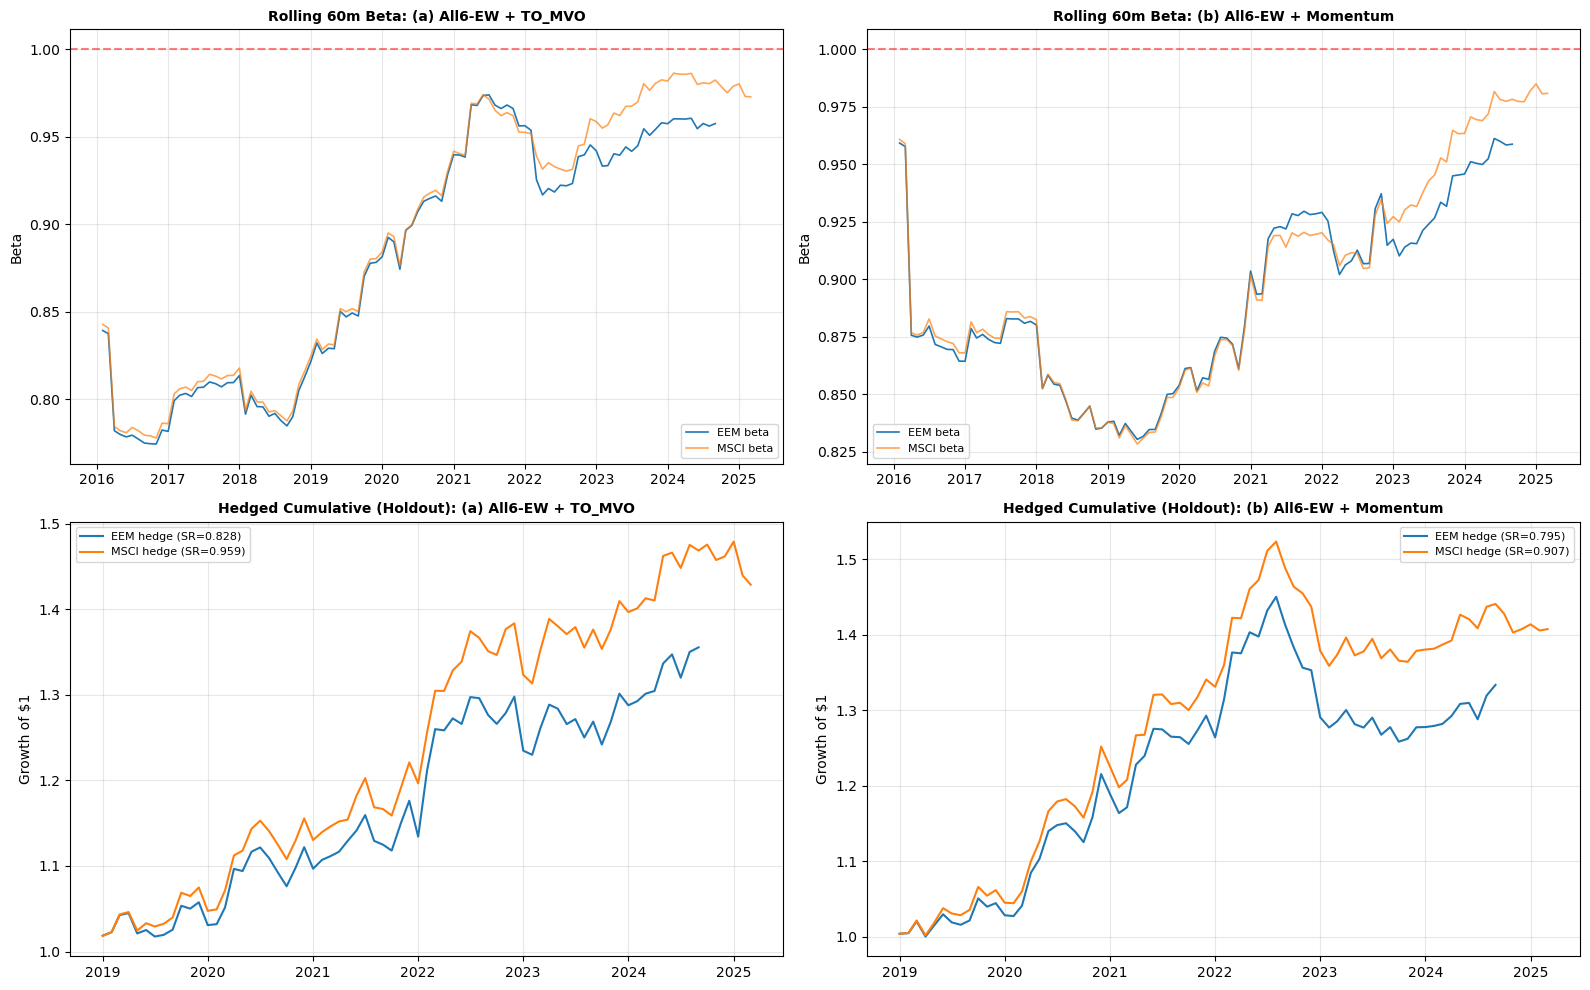

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, (label, info) in enumerate(STRATS.items()):
    ax = axes[0, i]
    be = betas_eem[label].dropna()
    bm = betas_msci[label].dropna()
    ax.plot(be.index, be.values, lw=1.2, label='EEM beta')
    ax.plot(bm.index, bm.values, lw=1.2, label='MSCI beta', alpha=0.7)
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'Rolling 60m Beta: {label}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Beta')

    ax = axes[1, i]
    he_h = hedged_eem[label][hedged_eem[label].index >= HOLD_START]
    hm_h = hedged_msci[label][hedged_msci[label].index >= HOLD_START]
    if len(he_h) > 0:
        ax.plot((1+he_h).cumprod().index, (1+he_h).cumprod().values, lw=1.5,
                label=f'EEM hedge (SR={ann_sharpe(he_h):.3f})')
    if len(hm_h) > 0:
        ax.plot((1+hm_h).cumprod().index, (1+hm_h).cumprod().values, lw=1.5,
                label=f'MSCI hedge (SR={ann_sharpe(hm_h):.3f})')
    ax.set_title(f'Hedged Cumulative (Holdout): {label}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb09_beta_comparison.pdf', bbox_inches='tight')
plt.show()

## 5. Hedged Performance: EEM vs MSCI EM

In [6]:
print('HEDGED PERFORMANCE COMPARISON')
print('='*110)
for period, start, end in [('Dev (2014-2018)', pd.Timestamp('2014-01-01'), pd.Timestamp('2019-01-01')),
                            ('Holdout (2019-2024)', HOLD_START, None)]:
    print(f'\n--- {period} ---')
    print(f'  {"Strategy":30s} {"Hedge":6s} {"GrossSR":>8s} {"NetSR":>8s} {"AnnRet":>8s} {"Vol":>8s} {"MaxDD":>8s} {"N":>4s}')
    for label, info in STRATS.items():
        for hedge_name, h_dict in [('EEM', hedged_eem), ('MSCI', hedged_msci)]:
            h = h_dict[label]
            if start: h = h[h.index >= start]
            if end: h = h[h.index < end]
            if len(h) < 6: continue
            h_net = h - info['tc']
            print(f'  {label:30s} {hedge_name:6s} {ann_sharpe(h):8.3f} {ann_sharpe(h_net):8.3f} '
                  f'{h_net.mean()*12:7.2%} {h.std()*np.sqrt(12):7.2%} '
                  f'{max_dd(h):7.1%} {len(h):4d}')

print('\n--- Dividend impact (EEM vs MSCI hedge, holdout) ---')
for label in STRATS:
    he = hedged_eem[label]; he = he[he.index >= HOLD_START]
    hm = hedged_msci[label]; hm = hm[hm.index >= HOLD_START]
    if len(he) > 0 and len(hm) > 0:
        diff = ann_sharpe(hm) - ann_sharpe(he)
        print(f'  {label}: EEM SR={ann_sharpe(he):.3f}, MSCI SR={ann_sharpe(hm):.3f}, '
              f'MSCI overstates by {diff:.3f}')

HEDGED PERFORMANCE COMPARISON

--- Dev (2014-2018) ---
  Strategy                       Hedge   GrossSR    NetSR   AnnRet      Vol    MaxDD    N
  (a) All6-EW + TO_MVO           EEM      -0.010   -0.169  -1.10%   6.48%   -8.2%   35
  (a) All6-EW + TO_MVO           MSCI      0.209    0.048   0.31%   6.45%   -7.2%   35
  (b) All6-EW + Momentum         EEM       0.033   -0.284  -1.36%   4.78%   -5.0%   35
  (b) All6-EW + Momentum         MSCI      0.348    0.039   0.19%   4.90%   -4.5%   35

--- Holdout (2019-2024) ---
  Strategy                       Hedge   GrossSR    NetSR   AnnRet      Vol    MaxDD    N
  (a) All6-EW + TO_MVO           EEM       0.828    0.673   4.48%   6.66%   -5.2%   69
  (a) All6-EW + TO_MVO           MSCI      0.959    0.791   4.87%   6.16%   -5.1%   75
  (b) All6-EW + Momentum         EEM       0.795    0.565   3.71%   6.57%  -13.2%   69
  (b) All6-EW + Momentum         MSCI      0.907    0.665   4.16%   6.25%  -10.8%   75

--- Dividend impact (EEM vs MSCI hedge,

## 6. Regression: EEM-Hedged vs MSCI-Hedged Returns

In [7]:
from scipy.stats import linregress

for label in STRATS:
    he = hedged_eem[label]
    hm = hedged_msci[label]
    aligned = pd.concat([he.rename('EEM'), hm.rename('MSCI')], axis=1).dropna()
    hh = aligned[aligned.index >= HOLD_START]

    if len(hh) < 12: continue

    corr = hh['EEM'].corr(hh['MSCI'])
    mad = (hh['EEM'] - hh['MSCI']).abs().mean()
    slope, intercept, _, _, _ = linregress(hh['MSCI'], hh['EEM'])

    print(f'{label}:')
    print(f'  Correlation of EEM vs MSCI hedged returns: {corr:.4f}')
    print(f'  Mean absolute monthly diff: {mad*100:.2f}% ({mad*10000:.0f} bps)')
    print(f'  Regression: EEM_hedged = {intercept:.4f} + {slope:.4f} × MSCI_hedged')
    print(f'    Intercept (ann): {intercept*12:.2%}')
    print(f'    Slope ≈ {slope:.3f} (1.0 = interchangeable)')
    print()

(a) All6-EW + TO_MVO:
  Correlation of EEM vs MSCI hedged returns: 0.9592
  Mean absolute monthly diff: 0.38% (38 bps)
  Regression: EEM_hedged = -0.0013 + 1.0283 × MSCI_hedged
    Intercept (ann): -1.57%
    Slope ≈ 1.028 (1.0 = interchangeable)

(b) All6-EW + Momentum:
  Correlation of EEM vs MSCI hedged returns: 0.9596
  Mean absolute monthly diff: 0.37% (37 bps)
  Regression: EEM_hedged = -0.0010 + 0.9841 × MSCI_hedged
    Intercept (ann): -1.24%
    Slope ≈ 0.984 (1.0 = interchangeable)



## 7. Sub-Period Analysis

In [8]:
print('SUB-PERIOD HEDGED PERFORMANCE (EEM Hedge, Gross)')
print('='*100)
midpoint = pd.Timestamp('2022-01-01')
for label in STRATS:
    he = hedged_eem[label]
    he_full = he[he.index >= HOLD_START]
    he_early = he[(he.index >= HOLD_START) & (he.index < midpoint)]
    he_late = he[he.index >= midpoint]

    print(f'\n{label}:')
    for pname, ps in [('Full Holdout', he_full), ('Early (2019-2021)', he_early), ('Late (2022-2024)', he_late)]:
        if len(ps) < 6: continue
        print(f'  {pname:25s}: Sharpe={ann_sharpe(ps):.3f}, Ann Ret={ps.mean()*12:.2%}, N={len(ps)}')

SUB-PERIOD HEDGED PERFORMANCE (EEM Hedge, Gross)

(a) All6-EW + TO_MVO:
  Full Holdout             : Sharpe=0.828, Ann Ret=5.52%, N=69
  Early (2019-2021)        : Sharpe=0.986, Ann Ret=5.58%, N=36
  Late (2022-2024)         : Sharpe=0.708, Ann Ret=5.45%, N=33

(b) All6-EW + Momentum:
  Full Holdout             : Sharpe=0.795, Ann Ret=5.23%, N=69
  Early (2019-2021)        : Sharpe=1.361, Ann Ret=8.79%, N=36
  Late (2022-2024)         : Sharpe=0.203, Ann Ret=1.34%, N=33


## 8. Save Hedged Returns

In [9]:
save_df = pd.DataFrame()
for label, info in STRATS.items():
    tag = 'A' if 'TO_MVO' in label else 'B'
    save_df[f'{tag}_long'] = pc_ret[info['col']]
    save_df[f'{tag}_hedged_eem'] = hedged_eem[label]
    save_df[f'{tag}_hedged_msci'] = hedged_msci[label]
    save_df[f'{tag}_beta_eem'] = betas_eem[label]
    save_df[f'{tag}_beta_msci'] = betas_msci[label]

save_df['EEM_ret'] = eem_ret
save_df['MSCI_ret'] = msci_ret
save_df.to_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv')
print(f'Saved to {OUTPUT_DIR}/csv/nb09_hedged_returns.csv')
print(f'Columns: {list(save_df.columns)}')

Saved to ../output/csv/nb09_hedged_returns.csv
Columns: ['A_long', 'A_hedged_eem', 'A_hedged_msci', 'A_beta_eem', 'A_beta_msci', 'B_long', 'B_hedged_eem', 'B_hedged_msci', 'B_beta_eem', 'B_beta_msci', 'EEM_ret', 'MSCI_ret']
